# Notebook demonstrating use of SEG-D rev 3.0 reader code on Stryde node data

In [1]:
from SEGD_rev3_reader import SEG_D_to_stream

In [2]:
# Read data as obspy stream, which can then be saved as mseed etc

'''
Required inputs:
- filepath: path to segd file (str) or list of paths to segd files (merges multiple files into one stream)

Optional arguments:
- convert_to_int: bool (default True), converts trace data to integer type
- serial_to_station_name_dict: dict (default None), assigns station codes and other info from dictionary (see further down)
- network_code: str (default 'AA'), network code for data (required for obspy)
- remove_gaps: bool (default False), skips traces where starttime is 1980-01-01 00:00:00 (GPS not locked)
'''

st = SEG_D_to_stream('./1.101_19_00_00_SN_2402041994_0.rsamp.segd')
st.sort()

1 Trace(s) in Stream:
AA.line_1_point_101..DNZ | 2024-08-11T19:00:00.000000Z - 2024-08-11T20:01:27.998000Z | 500.0 Hz, 1844000 samples

In [3]:
# Look at trace stats:
st[0].stats

         network: AA
         station: line_1_point_101
        location: 
         channel: DNZ
       starttime: 2024-08-11T19:00:00.000000Z
         endtime: 2024-08-11T20:01:27.998000Z
   sampling_rate: 500.0
           delta: 0.002
            npts: 1844000
           calib: 1.0
            segd: AttribDict({'serialNumber': 'line_1_point_101', 'fileNumber': 10008, 'SEGDVersion': '3.0', 'year': '24', 'jday': '224', 'hour': '19', 'minute': '00', 'second': '00', 'duration_microsec': 3688000000, 'dominant_sampling_interval_microsec': 2000, 'record_timezero_utc': UTCDateTime(2024, 8, 11, 19, 0), 'trace_format_code': '8036', 'headerSize_bytes': 17568, 'gainControl': 'Fixed gain', 'aliasFilterFrequency': 125.0, 'lowCutFilterFrequency': 0.5, 'aliasFilterSlope': 120.0, 'lowCutFilterSlope': 18.0, 'notchFrequency': 0.0, 'secondNotchFrequency': 0.0, 'thirdNotchFrequency': 0.0, 'filterPhase': 'Zero', 'filterDelaySecs': 0.0, 'DSM': 1.309999930754202e-07, 'physicalUnit': 'm/s/s'})

In [4]:
# Look at first trace data (if convert_to_int=False, these will be float type)
st[0].data

array([1369, 1796, 1063, ..., 4272, 5003, 4307], dtype=int32)

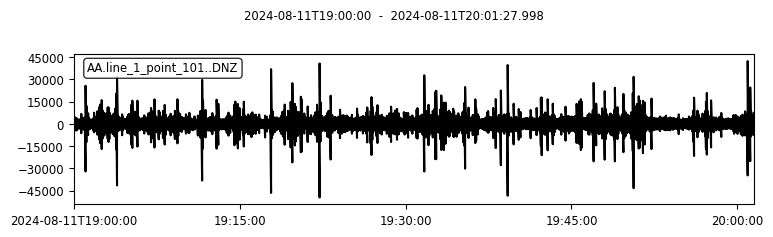

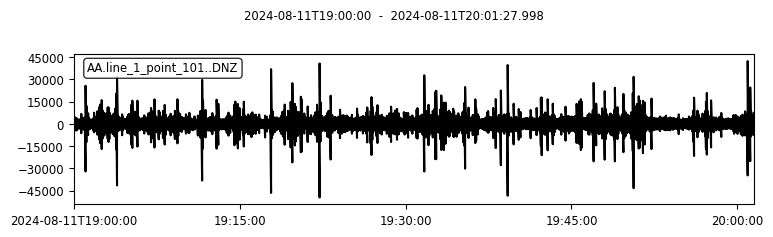

In [5]:
# Plot trace
st.plot(equal_scale=False)